In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
root="C:/Users/nefel/Desktop/Virality-on-Shorts" # TO CHANGE according to your local path

# Data loading
instagram = pd.read_csv(root + "/data/clean/instagram_clean.csv")
tiktok = pd.read_csv(root + "/data/clean/tiktok_clean.csv")
youtube = pd.read_csv(root + "/data/clean/youtube_clean.csv")


# Dataset Overview

In [2]:
# Store datasets in a dictionary so that the same analysis can be applied
# consistently to YouTube, Instagram, and TikTok.
datasets = {
    "YouTube": youtube,
    "Instagram": instagram,
    "TikTok": tiktok,
}

overview = []

for platform, df in datasets.items():

    temp = df.copy()
    # Convert publication dates to timezone-aware datetime objects.
    # This allows consistent filtering and aggregation by year/month across platforms.
    temp["published_at"] = pd.to_datetime(temp["published_at"], utc=True)

    overview.append({
        "Platform": platform,
        "Videos": len(temp),
        "Publishers": temp["publisher"].nunique(),
        "First upload": temp["published_at"].min().date(),
        "Last upload": temp["published_at"].max().date(),
    })

overview_df = pd.DataFrame(overview)

overview_df

,Platform,Videos,Publishers,First upload,Last upload
0,YouTube,51858,130,2022-01-01,2026-05-31
1,Instagram,233279,161,2022-10-01,2026-06-08
2,TikTok,194812,160,2022-01-01,2026-06-24


In [3]:
# =============================================================================
# CHECK ENGAGEMENT RATE SANITY AFTER FILTERING
# =============================================================================

rate_sanity_summary = []

for platform, df in datasets.items():

    temp = df.copy()

    for col in ["views", "likes", "comments", "like_rate", "comment_rate", "engagement_rate"]:
        temp[col] = pd.to_numeric(
            temp[col],
            errors="coerce"
        )

    temp["interactions"] = temp["likes"] + temp["comments"]

    rate_sanity_summary.append({
        "platform": platform,
        "n_videos": len(temp),

        "likes_gt_views": (temp["likes"] > temp["views"]).sum(),
        "interactions_gt_views": (temp["interactions"] > temp["views"]).sum(),

        "median_like_rate_%": temp["like_rate"].median() * 100,
        "p99_like_rate_%": temp["like_rate"].quantile(0.99) * 100,
        "max_like_rate_%": temp["like_rate"].max() * 100,

        "median_comment_rate_%": temp["comment_rate"].median() * 100,
        "p99_comment_rate_%": temp["comment_rate"].quantile(0.99) * 100,
        "max_comment_rate_%": temp["comment_rate"].max() * 100,

        "median_engagement_rate_%": temp["engagement_rate"].median() * 100,
        "p99_engagement_rate_%": temp["engagement_rate"].quantile(0.99) * 100,
        "max_engagement_rate_%": temp["engagement_rate"].max() * 100,

        "engagement_rate_gt_100pct": (temp["engagement_rate"] > 1).sum(),
        "engagement_rate_gt_50pct": (temp["engagement_rate"] > 0.5).sum(),
        "engagement_rate_gt_25pct": (temp["engagement_rate"] > 0.25).sum(),
    })

rate_sanity_summary = (
    pd.DataFrame(rate_sanity_summary)
    .round(3)
)

display(rate_sanity_summary)

,platform,n_videos,likes_gt_views,interactions_gt_views,median_like_rate_%,p99_like_rate_%,max_like_rate_%,median_comment_rate_%,p99_comment_rate_%,max_comment_rate_%,median_engagement_rate_%,p99_engagement_rate_%,max_engagement_rate_%,engagement_rate_gt_100pct,engagement_rate_gt_50pct,engagement_rate_gt_25pct
0,YouTube,51858,0,0,1.117,7.606,75.000,0.055,1.513,15.414,1.266,8.081,75.000,0,2,13
1,Instagram,233279,0,84,1.200,27.604,100.000,0.030,1.489,124.346,1.272,29.113,222.736,84,1169,2772
2,TikTok,194812,0,0,2.172,12.043,44.537,0.046,1.077,9.926,2.293,12.285,44.773,0,0,84


# Publisher activity

## Videos per publisher

In [5]:
# Create a list that will store publisher-level activity summaries
# for each platform separately.
publisher_stats = []

# Loop through each platform dataset using the shared dictionary structure.
for platform, df in datasets.items():

    # Count the total number of videos produced by each publisher.
    # This gives one row per publisher, with the number of videos they uploaded
    # across the full observation period.
    counts = (
        df.groupby("publisher")
          .size()
          .rename("n_videos")
    )

    # Print a compact descriptive summary of publisher activity for this platform.
    print(f"\n{'='*60}")
    print(platform)
    print("="*60)

    print(counts.describe())

    publisher_stats.append(
        pd.DataFrame({
            "platform": platform,
            "publisher": counts.index,
            "n_videos": counts.values
        })
    )

publisher_stats = pd.concat(publisher_stats, ignore_index=True)


YouTube
count     130.000000
mean      398.907692
std       862.242978
min         1.000000
25%        10.000000
50%        87.000000
75%       344.500000
max      6798.000000
Name: n_videos, dtype: float64

Instagram
count      161.000000
mean      1448.937888
std       2124.491332
min          1.000000
25%        257.000000
50%        656.000000
75%       1540.000000
max      13990.000000
Name: n_videos, dtype: float64

TikTok
count      160.000000
mean      1217.575000
std       2238.805638
min          1.000000
25%        121.500000
50%        437.000000
75%       1224.000000
max      14732.000000
Name: n_videos, dtype: float64


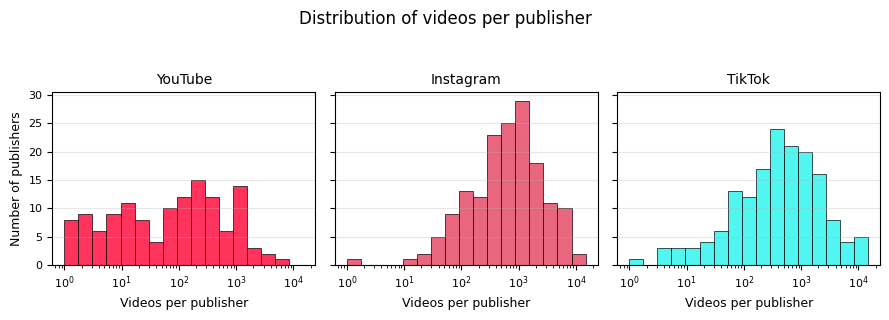

In [6]:
COLORS = {
    "Instagram": "#E4405F",
    "TikTok": "#25F4EE",
    "YouTube": "#FF0033",
}

xmin = publisher_stats["n_videos"].min()
xmax = publisher_stats["n_videos"].max()

bins = np.logspace(
    np.log10(xmin),
    np.log10(xmax),
    18
)

fig, axes = plt.subplots(
    1, 3,
    figsize=(9, 3),
    sharex=True,
    sharey=True
)

platforms = ["YouTube", "Instagram", "TikTok"]

for ax, platform in zip(axes, platforms):

    sub = publisher_stats[
        publisher_stats["platform"] == platform
    ]

    ax.hist(
        sub["n_videos"],
        bins=bins,
        edgecolor="black",
        alpha=0.8,
        color=COLORS[platform],
        linewidth=0.6
    )

    ax.set_xscale("log")
    ax.set_title(platform, fontsize=10)
    ax.set_xlabel("Videos per publisher", fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="both", labelsize=8)

axes[0].set_ylabel("Number of publishers", fontsize=9)

plt.suptitle(
    "Distribution of videos per publisher",
    fontsize=12,
    y=1.05
)

plt.tight_layout()
plt.show()

## Typical Monthly Publisher Activity

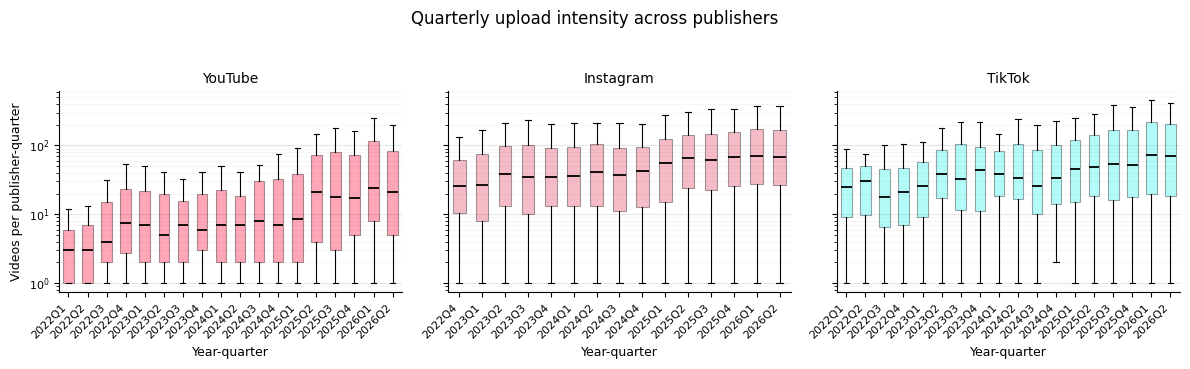

In [10]:
# =============================================================================
# PUBLISHER QUARTERLY UPLOAD INTENSITY
# Boxplots by year-quarter: 2022Q1, 2022Q2, ..., 2026Q2
# One panel per platform
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

platform_order = ["YouTube", "Instagram", "TikTok"]

# ---------------------------------------------------------
# 1. Build publisher-quarter counts
# Each row = one publisher in one platform-year-quarter
# ---------------------------------------------------------

publisher_quarterly_counts = []

for platform, df in datasets.items():

    temp = df.copy()
    temp["platform"] = platform

    temp["published_at"] = pd.to_datetime(
        temp["published_at"],
        utc=True,
        errors="coerce"
    )

    temp = temp.dropna(subset=["published_at", "publisher"])

    temp["year"] = temp["published_at"].dt.year

    # Convert to quarter period, e.g. 2022Q1, 2022Q2, ...
    temp["year_quarter"] = (
        temp["published_at"]
        .dt.tz_convert(None)
        .dt.to_period("Q")
    )

    counts = (
        temp.groupby(["platform", "publisher", "year", "year_quarter"])
            .size()
            .rename("videos_in_quarter")
            .reset_index()
    )

    publisher_quarterly_counts.append(counts)

publisher_quarterly_counts = pd.concat(
    publisher_quarterly_counts,
    ignore_index=True
)

# ---------------------------------------------------------
# 2. Plot boxplots by year-quarter
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 3.5),
    sharey=True
)

for ax, platform in zip(axes, platform_order):

    sub = publisher_quarterly_counts[
        publisher_quarterly_counts["platform"] == platform
    ].copy()

    quarters = sorted(sub["year_quarter"].unique())

    boxplot_data = [
        sub.loc[
            sub["year_quarter"] == quarter,
            "videos_in_quarter"
        ].values
        for quarter in quarters
    ]

    labels = [str(q) for q in quarters]
    positions = np.arange(1, len(quarters) + 1)

    ax.boxplot(
        boxplot_data,
        positions=positions,
        showfliers=False,
        patch_artist=True,
        widths=0.55,
        boxprops=dict(
            facecolor=COLORS[platform],
            alpha=0.35,
            edgecolor="black",
            linewidth=0.8
        ),
        medianprops=dict(
            color="black",
            linewidth=1.3
        ),
        whiskerprops=dict(
            color="black",
            linewidth=0.8
        ),
        capprops=dict(
            color="black",
            linewidth=0.8
        )
    )

    ax.set_yscale("log")

    ax.set_title(platform, fontsize=10, color="black")
    ax.set_xlabel("Year-quarter", fontsize=9)

    # Show every second quarter label to keep the x-axis readable
    show_every = 1

    ax.set_xticks(positions[::show_every])
    ax.set_xticklabels(
        labels[::show_every],
        rotation=45,
        ha="right",
        fontsize=8
    )

    ax.grid(
        axis="y",
        which="major",
        alpha=0.3
    )

    ax.grid(
        axis="y",
        which="minor",
        alpha=0.1
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(axis="y", labelsize=8)

axes[0].set_ylabel("Videos per publisher-quarter", fontsize=9)

plt.suptitle(
    "Quarterly upload intensity across publishers",
    fontsize=12,
    y=1.04
)

plt.tight_layout()
plt.show()

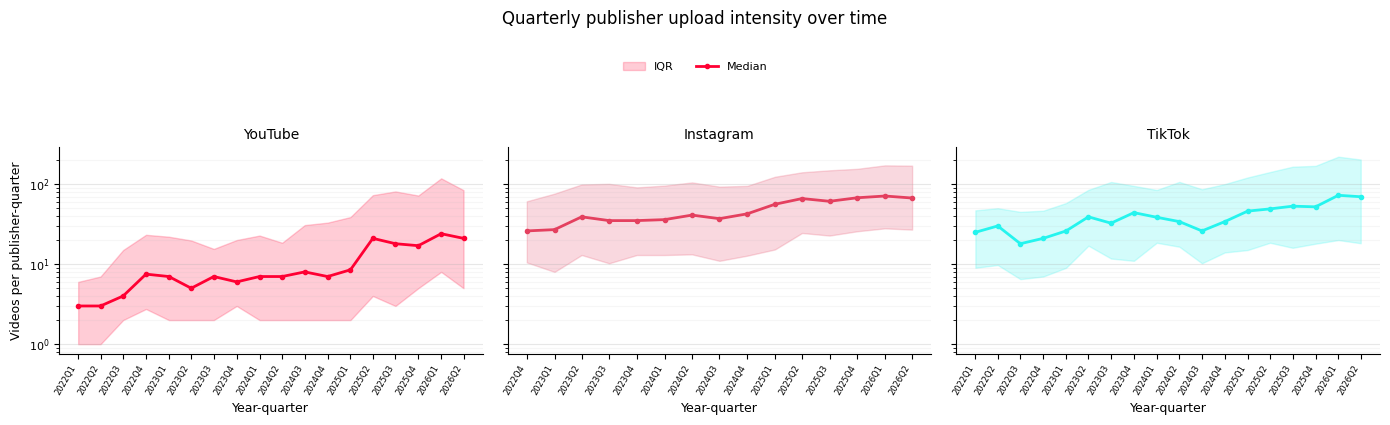

In [ ]:
# =============================================================================
# QUARTERLY UPLOAD INTENSITY
# Median + IQR over time
# =============================================================================
platform_order = ["YouTube", "Instagram", "TikTok"]

# ---------------------------------------------------------
# 1. Summarize publisher-quarter activity
# ---------------------------------------------------------

quarterly_upload_summary = (
    publisher_quarterly_counts
    .groupby(["platform", "year_quarter"])["videos_in_quarter"]
    .agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        mean="mean",
        n_publishers="count"
    )
    .reset_index()
)

quarterly_upload_summary["year_quarter_date"] = (
    quarterly_upload_summary["year_quarter"]
    .dt.to_timestamp()
)

quarterly_upload_summary["year_quarter_label"] = (
    quarterly_upload_summary["year_quarter"]
    .astype(str)
)

# ---------------------------------------------------------
# 2. Plot median + IQR with all quarter labels
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1, 3,
    figsize=(14, 3.5),
    sharey=True
)

for ax, platform in zip(axes, platform_order):

    sub = (
        quarterly_upload_summary[
            quarterly_upload_summary["platform"] == platform
        ]
        .sort_values("year_quarter_date")
        .copy()
    )

    ax.fill_between(
        sub["year_quarter_date"],
        sub["q25"],
        sub["q75"],
        color=COLORS[platform],
        alpha=0.20,
        label="IQR"
    )

    ax.plot(
        sub["year_quarter_date"],
        sub["median"],
        color=COLORS[platform],
        linewidth=2,
        marker="o",
        markersize=3,
        label="Median"
    )

    ax.set_yscale("log")

    ax.set_title(platform, fontsize=10)
    ax.set_xlabel("Year-quarter", fontsize=9)

    # Show all year-quarter labels
    ax.set_xticks(sub["year_quarter_date"])

    ax.set_xticklabels(
        sub["year_quarter_label"],
        rotation=60,
        ha="right",
        fontsize=6
    )

    ax.grid(
        axis="y",
        which="major",
        alpha=0.3
    )

    ax.grid(
        axis="y",
        which="minor",
        alpha=0.1
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(axis="y", labelsize=8)

axes[0].set_ylabel("Videos per publisher-quarter", fontsize=9)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=2,
    frameon=False,
    fontsize=8
)

plt.suptitle(
    "Quarterly publisher upload intensity over time",
    fontsize=12,
    y=1.20
)

plt.tight_layout()
plt.show()

In [9]:
# =============================================================================
# QUARTERLY UPLOAD INTENSITY SUMMARY TABLE
# Actual numbers behind the boxplots
# =============================================================================

quarterly_upload_summary = (
    publisher_quarterly_counts
    .groupby(["platform", "year_quarter"])["videos_in_quarter"]
    .agg(
        n_publisher_quarters="count",
        median_videos_per_publisher_quarter="median",
        mean_videos_per_publisher_quarter="mean",
        q25_videos_per_publisher_quarter=lambda x: x.quantile(0.25),
        q75_videos_per_publisher_quarter=lambda x: x.quantile(0.75),
        min_videos_per_publisher_quarter="min",
        max_videos_per_publisher_quarter="max"
    )
    .reset_index()
)

quarterly_upload_summary["year_quarter"] = quarterly_upload_summary[
    "year_quarter"
].astype(str)

quarterly_upload_summary = quarterly_upload_summary.round(2)

display(quarterly_upload_summary)

,platform,year_quarter,n_publisher_quarters,median_videos_per_publisher_quarter,mean_videos_per_publisher_quarter,q25_videos_per_publisher_quarter,q75_videos_per_publisher_quarter,min_videos_per_publisher_quarter,max_videos_per_publisher_quarter
0,Instagram,2022Q4,131,26.0,62.92,10.50,61.00,1,718
1,Instagram,2023Q1,137,27.0,65.53,8.00,76.00,1,681
2,Instagram,2023Q2,141,39.0,74.76,13.00,99.00,1,642
3,Instagram,2023Q3,142,35.0,78.18,10.25,100.75,1,692
4,Instagram,2023Q4,145,35.0,85.80,13.00,91.00,1,1116
5,Instagram,2024Q1,144,36.0,91.10,13.00,95.75,1,771
6,Instagram,2024Q2,146,41.0,94.57,13.25,105.00,1,651
7,Instagram,2024Q3,145,37.0,87.80,11.00,93.00,1,666
8,Instagram,2024Q4,152,42.5,94.04,12.75,95.00,1,799
9,Instagram,2025Q1,150,56.0,115.87,15.25,123.50,1,1189


In [8]:
# Create a list to store monthly publisher upload counts
publisher_monthly_counts = []

for platform, df in datasets.items():

    temp = df.copy()
    temp["platform"] = platform
    temp["published_at"] = pd.to_datetime(
        temp["published_at"],
        utc=True,
        errors="coerce"
    )

    temp = temp.dropna(subset=["published_at", "publisher"])

    temp["year"] = temp["published_at"].dt.year
    temp["year_month"] = temp["published_at"].dt.to_period("M")

    # Count how many videos each publisher uploaded in each month.
    # Each row represents one publisher-platform-month combination.
    counts = (
        temp.groupby(["platform", "publisher", "year", "year_month"])
            .size()
            .rename("videos_in_month")
            .reset_index()
    )

    publisher_monthly_counts.append(counts)

publisher_monthly_counts = pd.concat(
    publisher_monthly_counts,
    ignore_index=True
)

# Summarize monthly upload intensity by platform and year.
monthly_upload_summary = (
    publisher_monthly_counts
    .groupby(["platform", "year"])["videos_in_month"]
    .agg(
        median_publisher_month="median",
        mean_publisher_month="mean",
        max_publisher_month="max"
    )
    .reset_index()
    .round(2)
)

display(max_monthly_uploads)

C:\Users\nefel\AppData\Local\Temp\ipykernel_7448\1241799125.py:17: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  temp["year_month"] = temp["published_at"].dt.to_period("M")
C:\Users\nefel\AppData\Local\Temp\ipykernel_7448\1241799125.py:17: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  temp["year_month"] = temp["published_at"].dt.to_period("M")
C:\Users\nefel\AppData\Local\Temp\ipykernel_7448\1241799125.py:17: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  temp["year_month"] = temp["published_at"].dt.to_period("M")


,platform,year,median_publisher_month,mean_publisher_month,max_publisher_month
0,Instagram,2022,10.0,23.35,263
1,Instagram,2023,13.0,27.94,461
2,Instagram,2024,15.0,33.66,461
3,Instagram,2025,22.0,49.34,800
4,Instagram,2026,24.0,55.08,876
5,TikTok,2022,9.0,15.53,167
6,TikTok,2023,14.0,27.49,200
7,TikTok,2024,13.0,29.49,229
8,TikTok,2025,20.0,55.66,1387
9,TikTok,2026,27.0,82.09,1158


In [ ]:
# Identify the single most active publisher-month for each platform-year.
# This shows which publisher produced the highest number of videos
# in any one month within each year and platform.
max_publisher_month_rows = (
    publisher_monthly_counts
    .sort_values("videos_in_month", ascending=False)
    .groupby(["platform", "year"])
    .head(1)
    .sort_values(["platform", "year"])
    .reset_index(drop=True)
)

display(max_publisher_month_rows)

,platform,publisher,year,year_month,videos_in_month
0,Instagram,The Epoch Times,2022,2022-10,263
1,Instagram,The Epoch Times,2023,2023-11,461
2,Instagram,The Epoch Times,2024,2024-01,461
3,Instagram,la Repubblica,2025,2025-10,800
4,Instagram,la Repubblica,2026,2026-05,876
5,TikTok,fanpage.it,2022,2022-11,167
6,TikTok,fanpage.it,2023,2023-11,200
7,TikTok,corrieredellasera,2024,2024-12,229
8,TikTok,voxnews.al,2025,2025-10,1387
9,TikTok,voxnews.al,2026,2026-05,1158


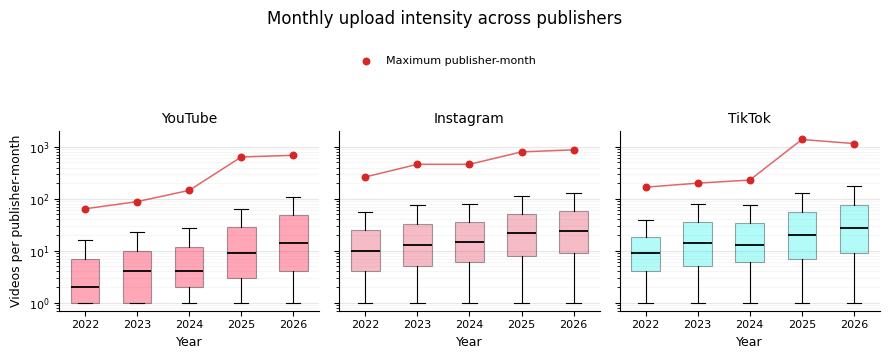

In [10]:
# =============================================================================
# PUBLISHER MONTHLY UPLOAD INTENSITY
# Boxplots by year + maximum publisher-month overlay
# =============================================================================
platform_order = ["YouTube", "Instagram", "TikTok"]

fig, axes = plt.subplots(
    1, 3,
    figsize=(9, 3),
    sharey=True
)

for ax, platform in zip(axes, platform_order):

    sub = publisher_monthly_counts[
        publisher_monthly_counts["platform"] == platform
    ].copy()

    years = sorted(sub["year"].unique())

    boxplot_data = [
        sub.loc[
            sub["year"] == year,
            "videos_in_month"
        ].values
        for year in years
    ]

    max_values = [
        sub.loc[
            sub["year"] == year,
            "videos_in_month"
        ].max()
        for year in years
    ]

    positions = np.arange(1, len(years) + 1)

    ax.boxplot(
        boxplot_data,
        positions=positions,
        showfliers=False,
        patch_artist=True,
        widths=0.55,
        boxprops=dict(
            facecolor=COLORS[platform],
            alpha=0.35,
            edgecolor="black",
            linewidth=0.8
        ),
        medianprops=dict(
            color="black",
            linewidth=1.3
        ),
        whiskerprops=dict(
            color="black",
            linewidth=0.8
        ),
        capprops=dict(
            color="black",
            linewidth=0.8
        )
    )

    # Overlay actual maximum publisher-month value
    ax.scatter(
        positions,
        max_values,
        color="#D62728",
        s=22,
        zorder=3,
        label="Maximum publisher-month"
    )

    ax.plot(
        positions,
        max_values,
        color="#D62728",
        linewidth=1.1,
        alpha=0.7
    )

    ax.set_yscale("log")

    ax.set_title(platform, fontsize=10, color="black")
    ax.set_xlabel("Year", fontsize=9)

    ax.set_xticks(positions)
    ax.set_xticklabels(years, fontsize=8)

    ax.grid(
        axis="y",
        which="major",
        alpha=0.3
    )

    ax.grid(
        axis="y",
        which="minor",
        alpha=0.1
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(axis="y", labelsize=8)

axes[0].set_ylabel("Videos per publisher-month", fontsize=9)

handles, labels = axes[-1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.06),
    frameon=False,
    fontsize=8
)

plt.suptitle(
    "Monthly upload intensity across publishers",
    fontsize=12,
    y=1.18
)

plt.tight_layout()
plt.show()

# Performance Distributions: Views, Likes and Comments

In [11]:
metrics = ["views", "likes", "comments"]
metric_labels = {
    "views": "Views",
    "likes": "Likes",
    "comments": "Comments",
}
platform_order = ["YouTube", "Instagram", "TikTok"]

# ---------------------------------------------------------
# Data Preparation
# ---------------------------------------------------------
# This function combines the three separate platform datasets into one
# long-form dataframe. This structure is useful for cross-platform plotting
# because each row keeps both the platform identity and the original metrics.
# ---------------------------------------------------------
def prepare_long_data(datasets, metrics, platform_order):
    """Combines separate datasets into one long-form DataFrame with log values."""
    all_data = []
    
    for platform in platform_order:
        df = datasets[platform].copy()
        # Add a column identifying the platform
        df['Platform'] = platform
        
        # Process each metric
        for metric in metrics:
            # Convert to numeric, coerce errors to NaN, drop NaNs
            values = pd.to_numeric(df[metric], errors="coerce").dropna()
            # Keep only positive values
            values = values[values >= 0]
            # Create the log10 column
            df[f'log10_{metric}'] = np.log10(values + 1)
            
        all_data.append(df)
        
    return pd.concat(all_data, ignore_index=True)


def plot_powerlaw_loglog(df_long, metrics, metric_labels, platform_order, COLORS):
    fig, axes = plt.subplots(1, len(metrics), figsize=(12, 4), sharey=True)
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        
        for platform in platform_order:
            # Filter for this platform and ensure we have raw numeric data
            plat_data = df_long[df_long['Platform'] == platform]
            vals = pd.to_numeric(plat_data[metric], errors="coerce").dropna()
            
            # For a log-log plot, we need values >= 1 (since log(0) is undefined)
            vals = vals[vals >= 1]
            
            if len(vals) == 0:
                continue
                
            # Create 50 logarithmically spaced bins from 10^0 (1) to the max value
            bins = np.logspace(0, np.log10(vals.max()), num=50)
            
            # Count how many posts fall into each logarithmic bin
            counts, bin_edges = np.histogram(vals, bins=bins)
            
            # Find the center of each bin for plotting the dot
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            
            # Remove empty bins to avoid plotting issues
            mask = counts > 0
            
            # Plot as a scatter plot
            ax.scatter(
                bin_centers[mask], 
                counts[mask], 
                s=12,          
                alpha=0.4,     
                color=COLORS[platform],
                label=platform
            )
            
        # Set both axes to logarithmic scale (the defining feature of this plot)
        ax.set_xscale('log')
        ax.set_yscale('log')
        
        ax.set_title(f"{metric_labels[metric]}", fontsize=12)
        ax.set_xlabel(f"Number of {metric_labels[metric].lower()}", fontsize=10)
        
        if i == 0:
            ax.set_ylabel("Number of posts", fontsize=10)
            
        # Clean up the spines (borders)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # Create a single clean legend at the top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.15), 
               ncol=len(platform_order), frameon=False, fontsize=11, markerscale=2)
    
    plt.tight_layout()
    plt.show()


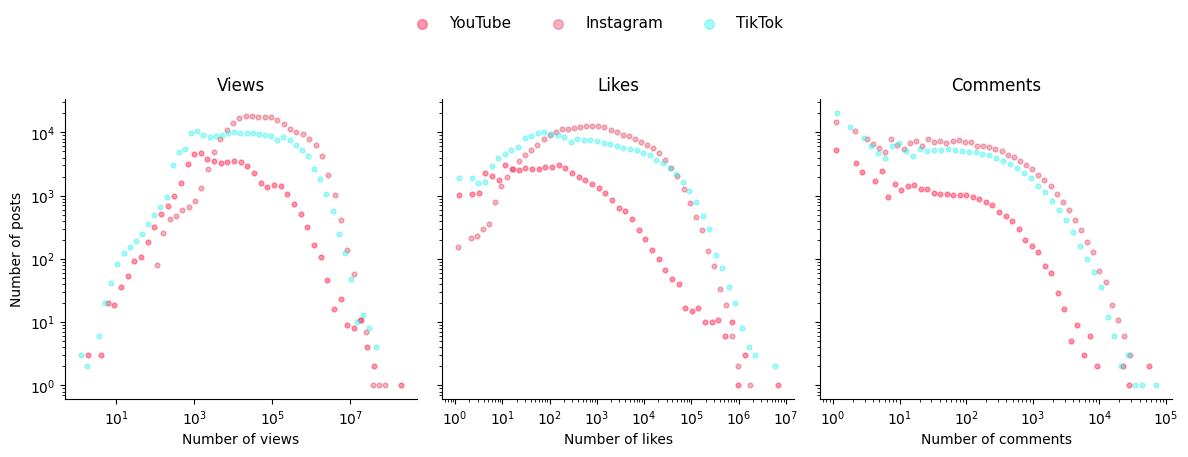

In [12]:
df_long = prepare_long_data(datasets, metrics, platform_order)
plot_powerlaw_loglog(df_long, metrics, metric_labels, platform_order, COLORS)

## Top 5 Publishers Performance Distribution

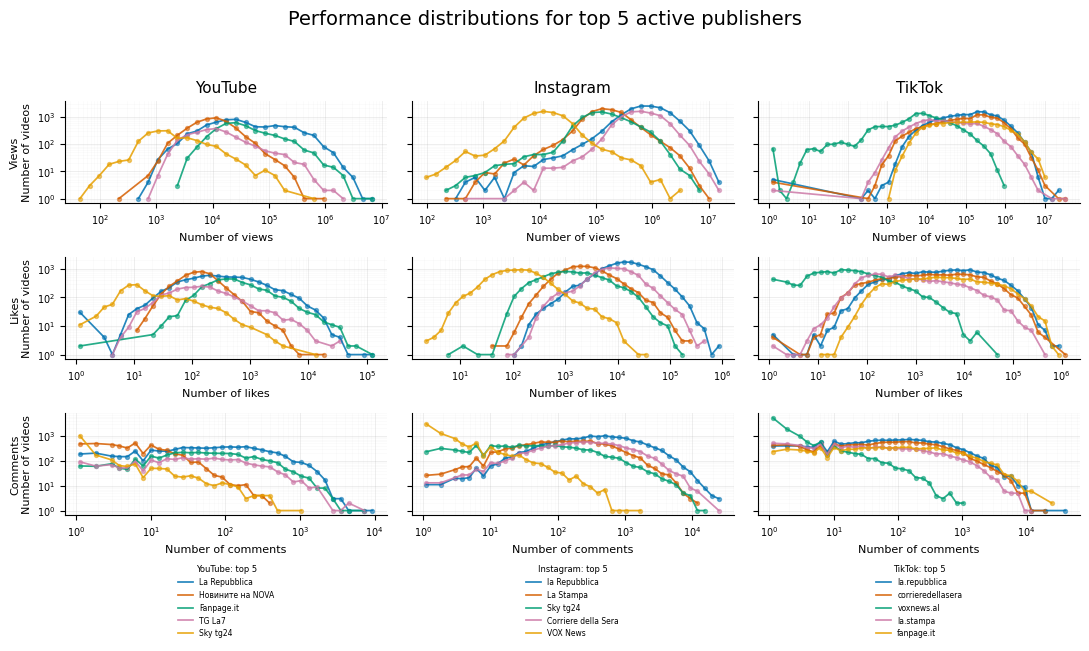

In [13]:
# =============================================================================
# TOP ACTIVE PUBLISHERS PERFORMANCE DISTRIBUTIONS
# 9 plots in one figure:
# rows = views, likes, comments
# columns = YouTube, Instagram, TikTok
# Inside each panel: top N most active publishers for that platform
# =============================================================================

import matplotlib.ticker as mticker

metrics = ["views", "likes", "comments"]

metric_labels = {
    "views": "Views",
    "likes": "Likes",
    "comments": "Comments",
}

platform_order = ["YouTube", "Instagram", "TikTok"]

TOP_N = 5
N_BINS = 45

# ---------------------------------------------------------
# Find top N most active publishers per platform
# based on total number of videos across all years
# ---------------------------------------------------------

top_publishers_by_platform = {}

for platform in platform_order:

    df = datasets[platform].copy()

    top_publishers = (
        df.groupby("publisher")
          .size()
          .sort_values(ascending=False)
          .head(TOP_N)
          .index
          .tolist()
    )

    top_publishers_by_platform[platform] = top_publishers


# More separable publisher colors
publisher_colors = [
    "#0072B2",  # blue
    "#D55E00",  # orange/red
    "#009E73",  # green
    "#CC79A7",  # purple/pink
    "#E69F00",  # amber
    "#56B4E9",  # light blue
    "#882255",  # wine
    "#44AA99",  # teal
    "#AA4499",  # magenta
    "#332288",  # dark purple
]

# ---------------------------------------------------------
# Plot all metrics and platforms in one figure
# ---------------------------------------------------------

fig, axes = plt.subplots(
    3, 3,
    figsize=(11, 7.5),
    sharex=False,
    sharey="row"
)

legend_handles = {}
legend_labels = {}

for row, metric in enumerate(metrics):

    # ---------------------------------------------------------
    # Define common x-axis bins for this metric
    # ---------------------------------------------------------
    all_values = []

    for platform in platform_order:

        df = datasets[platform].copy()

        df = df[
            df["publisher"].isin(top_publishers_by_platform[platform])
        ].copy()

        values = pd.to_numeric(
            df[metric],
            errors="coerce"
        ).dropna()

        values = values[
            (values >= 0) &
            np.isfinite(values)
        ] + 1

        all_values.append(values)

    all_values = pd.concat(
        all_values,
        ignore_index=True
    )

    bins = np.logspace(
        np.log10(all_values.min()),
        np.log10(all_values.max()),
        N_BINS
    )

    bin_centers = np.sqrt(
        bins[:-1] * bins[1:]
    )

    # ---------------------------------------------------------
    # Plot each platform
    # ---------------------------------------------------------
    for col, platform in enumerate(platform_order):

        ax = axes[row, col]

        df = datasets[platform].copy()

        top_publishers = top_publishers_by_platform[platform]

        legend_handles.setdefault(platform, [])
        legend_labels.setdefault(platform, [])

        for i, publisher in enumerate(top_publishers):

            color = publisher_colors[i]

            sub = df[df["publisher"] == publisher].copy()

            values = pd.to_numeric(
                sub[metric],
                errors="coerce"
            ).dropna()

            values = values[
                (values >= 0) &
                np.isfinite(values)
            ] + 1

            counts, _ = np.histogram(
                values,
                bins=bins
            )

            nonzero = counts > 0

            publisher_label = (
                publisher[:20] + "..."
                if len(publisher) > 23
                else publisher
            )

            line = ax.plot(
                bin_centers[nonzero],
                counts[nonzero],
                color=color,
                linewidth=1.25,
                alpha=0.85,
                label=publisher_label
            )[0]

            ax.scatter(
                bin_centers[nonzero],
                counts[nonzero],
                color=color,
                s=8,
                alpha=0.55
            )

            if row == 0:
                legend_handles[platform].append(line)
                legend_labels[platform].append(publisher_label)

        ax.set_xscale("log")
        ax.set_yscale("log")

        if row == 0:
            ax.set_title(platform, fontsize=11, color="black")

        if col == 0:
            ax.set_ylabel(
                f"{metric_labels[metric]}\nNumber of videos",
                fontsize=8
            )

        ax.set_xlabel(
            f"Number of {metric_labels[metric].lower()}",
            fontsize=8
        )

        ax.grid(
            which="major",
            alpha=0.25,
            linewidth=0.6
        )

        ax.grid(
            which="minor",
            alpha=0.08,
            linewidth=0.4
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.tick_params(
            axis="both",
            which="major",
            labelsize=7
        )

        ax.tick_params(
            axis="both",
            which="minor",
            length=0
        )

        ax.xaxis.set_major_locator(
            mticker.LogLocator(base=10)
        )

        ax.yaxis.set_major_locator(
            mticker.LogLocator(base=10)
        )

        ax.xaxis.set_minor_formatter(
            mticker.NullFormatter()
        )

        ax.yaxis.set_minor_formatter(
            mticker.NullFormatter()
        )


# ---------------------------------------------------------
# Add one compact legend per platform column
# ---------------------------------------------------------

for col, platform in enumerate(platform_order):

    axes[2, col].legend(
        legend_handles[platform],
        legend_labels[platform],
        frameon=False,
        fontsize=5.5,
        ncol=1,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.42),
        title=f"{platform}: top {TOP_N}",
        title_fontsize=6
    )

plt.suptitle(
    f"Performance distributions for top {TOP_N} active publishers",
    fontsize=14,
    y=0.98
)

plt.tight_layout(
    rect=[0, 0.08, 1, 0.95]
)

plt.show()

## Different Plot of Distributions

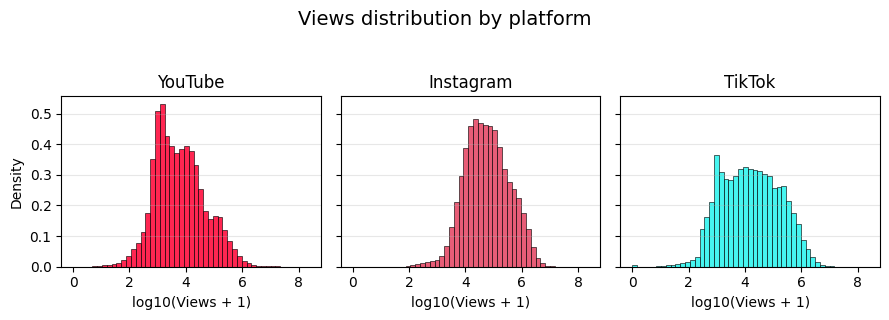

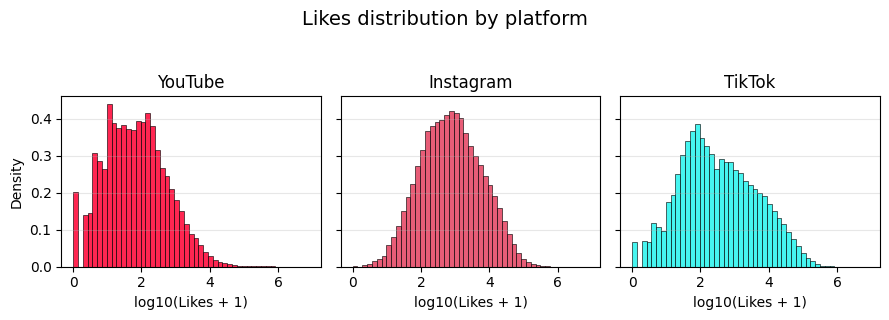

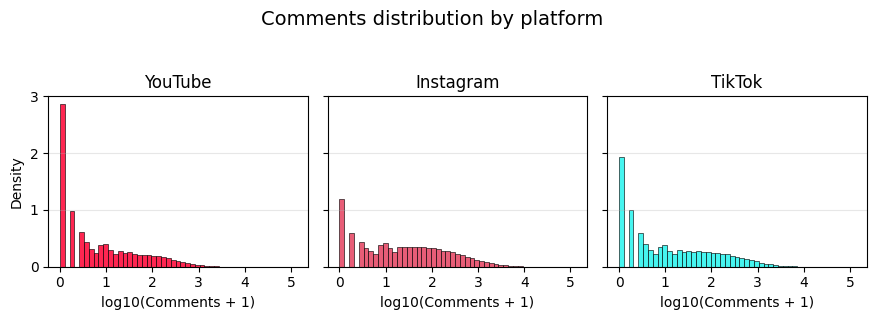

In [11]:
metrics = ["views", "likes", "comments"]

metric_labels = {
    "views": "Views",
    "likes": "Likes",
    "comments": "Comments",
}

platform_order = ["YouTube", "Instagram", "TikTok"]

for metric in metrics:

    fig, axes = plt.subplots(
        1, 3,
        figsize=(9, 3),
        sharex=True,
        sharey=True
    )

    # Use common bins across platforms for comparability
    all_values = []

    for platform in platform_order:
        values = pd.to_numeric(
            datasets[platform][metric],
            errors="coerce"
        ).dropna()

        values = values[values >= 0]

        all_values.append(np.log10(values + 1))

    all_values = pd.concat(
        [pd.Series(v) for v in all_values],
        ignore_index=True
    )

    bins = np.linspace(
        all_values.min(),
        all_values.max(),
        50
    )

    for ax, platform in zip(axes, platform_order):

        values = pd.to_numeric(
            datasets[platform][metric],
            errors="coerce"
        ).dropna()

        values = values[values >= 0]

        log_values = np.log10(values + 1)

        ax.hist(
            log_values,
            bins=bins,
            density=True,
            color=COLORS[platform],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.85
        )

        ax.set_title(platform)
        ax.set_xlabel(f"log10({metric_labels[metric]} + 1)")
        ax.grid(axis="y", alpha=0.3)

    axes[0].set_ylabel("Density")

    plt.suptitle(
        f"{metric_labels[metric]} distribution by platform",
        fontsize=14,
        y=1.05
    )

    plt.tight_layout()
    plt.show()

# Engagement rate distribution plots

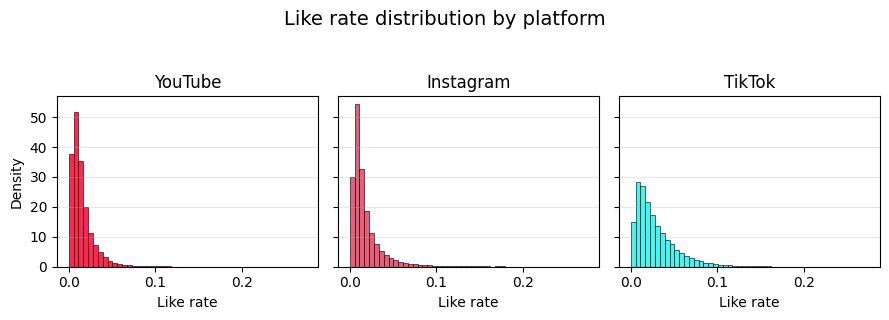

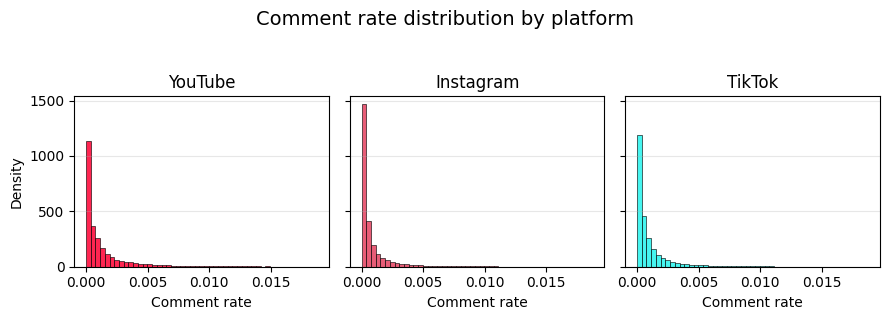

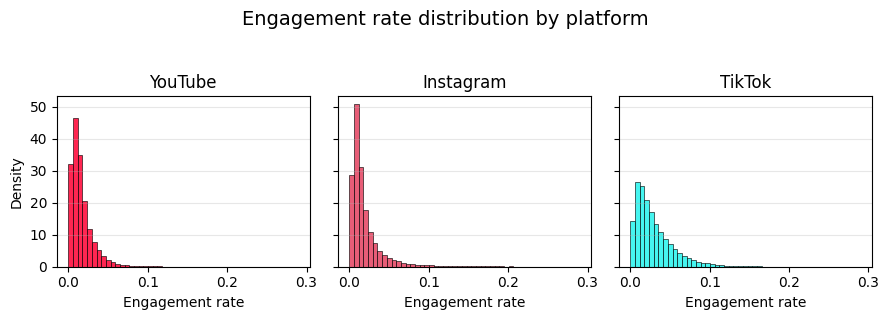

In [14]:
engagement_metrics = ["like_rate", "comment_rate", "engagement_rate"]

engagement_labels = {
    "like_rate": "Like rate",
    "comment_rate": "Comment rate",
    "engagement_rate": "Engagement rate",
}

platform_order = ["YouTube", "Instagram", "TikTok"]

for metric in engagement_metrics:

    fig, axes = plt.subplots(
        1, 3,
        figsize=(9, 3),
        sharex=True,
        sharey=True
    )

    all_values = []

    for platform in platform_order:

        values = pd.to_numeric(
            datasets[platform][metric],
            errors="coerce"
        ).dropna()

        values = values[values >= 0]

        all_values.append(values)

    all_values = pd.concat(all_values, ignore_index=True)

    # Remove extreme impossible values only for visualization
    upper_limit = all_values.quantile(0.995)

    bins = np.linspace(
        0,
        upper_limit,
        50
    )

    for ax, platform in zip(axes, platform_order):

        values = pd.to_numeric(
            datasets[platform][metric],
            errors="coerce"
        ).dropna()

        values = values[
            (values >= 0) &
            (values <= upper_limit)
        ]

        ax.hist(
            values,
            bins=bins,
            density=True,
            color=COLORS[platform],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.85
        )

        ax.set_title(platform)
        ax.set_xlabel(engagement_labels[metric])
        ax.grid(axis="y", alpha=0.3)

    axes[0].set_ylabel("Density")

    plt.suptitle(
        f"{engagement_labels[metric]} distribution by platform",
        fontsize=14,
        y=1.05
    )

    plt.tight_layout()
    plt.show()

#  MONTHLY ENGAGEMENT RATE BOXPLOTS BY PLATFORM

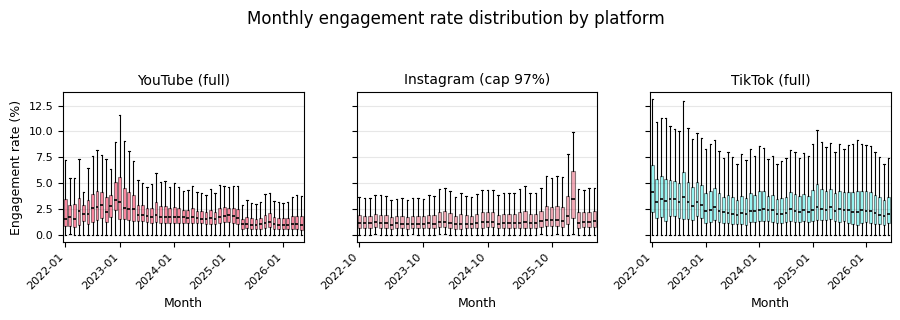

,platform,videos_before_plot_filter,videos_excluded_from_plot,videos_used_in_plot
0,YouTube,51856,0,51856
1,Instagram,233279,6999,226280
2,TikTok,194638,0,194638


In [15]:
ENGAGEMENT_COL = "engagement_rate"
RATE_IS_PROPORTION = True
# Percentile cap used only for visualization.
CAP_QUANTILE = 0.97   

platform_order = ["YouTube", "Instagram", "TikTok"]

plot_filter_report = []

fig, axes = plt.subplots(
    1, 3,
    figsize=(9, 3),
    sharey=True
)

for ax, platform in zip(axes, platform_order):

    df = datasets[platform].copy()

    df["published_at"] = pd.to_datetime(
        df["published_at"],
        utc=True,
        errors="coerce"
    )

    df[ENGAGEMENT_COL] = pd.to_numeric(
        df[ENGAGEMENT_COL],
        errors="coerce"
    )

    df = df.dropna(subset=["published_at", ENGAGEMENT_COL])

    df = df[
        (df[ENGAGEMENT_COL] >= 0) &
        np.isfinite(df[ENGAGEMENT_COL])
    ].copy()

    df["year_month"] = (
        df["published_at"]
        .dt.tz_convert(None)
        .dt.to_period("M")
    )

    # Convert to percentage for plotting
    if RATE_IS_PROPORTION:
        df["engagement_rate_plot"] = df[ENGAGEMENT_COL] * 100
    else:
        df["engagement_rate_plot"] = df[ENGAGEMENT_COL]

    before_plot_filter = len(df)

    # Apply percentile cap only to Instagram, only for visualization
    if platform == "Instagram":
        instagram_cap = df["engagement_rate_plot"].quantile(CAP_QUANTILE)

        df_plot = df[
            df["engagement_rate_plot"] <= instagram_cap
        ].copy()

        title_note = f"cap {int(CAP_QUANTILE * 100)}%"
    else:
        df_plot = df.copy()
        title_note = "full"

    after_plot_filter = len(df_plot)

    plot_filter_report.append({
        "platform": platform,
        "videos_before_plot_filter": before_plot_filter,
        "videos_excluded_from_plot": before_plot_filter - after_plot_filter,
        "videos_used_in_plot": after_plot_filter
    })

    months = sorted(df_plot["year_month"].unique())

    boxplot_data = [
        df_plot.loc[
            df_plot["year_month"] == month,
            "engagement_rate_plot"
        ].values
        for month in months
    ]

    labels = [str(month) for month in months]

    ax.boxplot(
        boxplot_data,
        showfliers=False,
        patch_artist=True,
        widths=0.6,
        boxprops=dict(
            facecolor=COLORS[platform],
            alpha=0.45,
            edgecolor="black",
            linewidth=0.8
        ),
        medianprops=dict(
            color="black",
            linewidth=1.2
        ),
        whiskerprops=dict(
            color="black",
            linewidth=0.8
        ),
        capprops=dict(
            color="black",
            linewidth=0.8
        )
    )

    ax.set_title(
        f"{platform} ({title_note})",
        fontsize=10
    )

    ax.set_xlabel("Month", fontsize=9)

    tick_positions = np.arange(1, len(months) + 1)

    # Compact labels: show every 12 months
    show_every = 12

    ax.set_xticks(tick_positions[::show_every])
    ax.set_xticklabels(
        labels[::show_every],
        rotation=45,
        ha="right",
        fontsize=8
    )

    ax.tick_params(axis="y", labelsize=8)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Engagement rate (%)", fontsize=9)

plt.suptitle(
    "Monthly engagement rate distribution by platform",
    fontsize=12,
    y=1.05
)

plt.tight_layout()
plt.show()

plot_filter_report = pd.DataFrame(plot_filter_report)

display(plot_filter_report)

## IQR

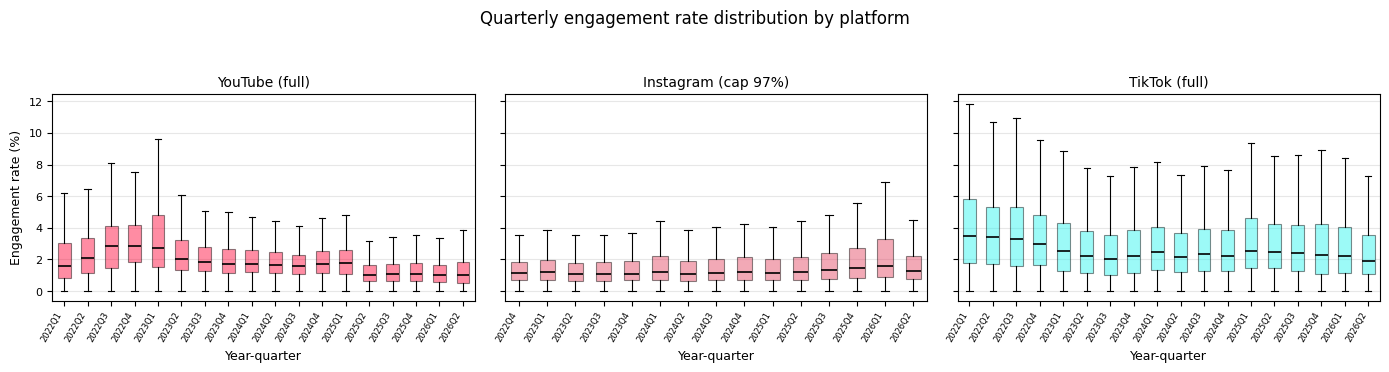

,platform,videos_before_plot_filter,videos_excluded_from_plot,videos_used_in_plot
0,YouTube,51856,0,51856
1,Instagram,233279,6999,226280
2,TikTok,194638,0,194638


In [13]:
# =============================================================================
# QUARTERLY ENGAGEMENT RATE BOXPLOTS
# One panel per platform
# x-axis = year-quarter
# y-axis = engagement rate (%)
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ENGAGEMENT_COL = "engagement_rate"
RATE_IS_PROPORTION = True

# Percentile cap used only for visualization
CAP_QUANTILE = 0.97

platform_order = ["YouTube", "Instagram", "TikTok"]

plot_filter_report = []

fig, axes = plt.subplots(
    1, 3,
    figsize=(14, 3.5),
    sharey=True
)

for ax, platform in zip(axes, platform_order):

    df = datasets[platform].copy()

    df["published_at"] = pd.to_datetime(
        df["published_at"],
        utc=True,
        errors="coerce"
    )

    df[ENGAGEMENT_COL] = pd.to_numeric(
        df[ENGAGEMENT_COL],
        errors="coerce"
    )

    df = df.dropna(subset=["published_at", ENGAGEMENT_COL])

    df = df[
        (df[ENGAGEMENT_COL] >= 0) &
        np.isfinite(df[ENGAGEMENT_COL])
    ].copy()

    # Convert dates into year-quarter periods, e.g. 2022Q1, 2022Q2
    df["year_quarter"] = (
        df["published_at"]
        .dt.tz_convert(None)
        .dt.to_period("Q")
    )

    # Convert engagement rate to percentage for plotting
    if RATE_IS_PROPORTION:
        df["engagement_rate_plot"] = df[ENGAGEMENT_COL] * 100
    else:
        df["engagement_rate_plot"] = df[ENGAGEMENT_COL]

    before_plot_filter = len(df)

    # Apply cap only to Instagram for visualization
    if platform == "Instagram":

        instagram_cap = df["engagement_rate_plot"].quantile(CAP_QUANTILE)

        df_plot = df[
            df["engagement_rate_plot"] <= instagram_cap
        ].copy()

        title_note = f"cap {int(CAP_QUANTILE * 100)}%"
    else:
        df_plot = df.copy()
        title_note = "full"

    after_plot_filter = len(df_plot)

    plot_filter_report.append({
        "platform": platform,
        "videos_before_plot_filter": before_plot_filter,
        "videos_excluded_from_plot": before_plot_filter - after_plot_filter,
        "videos_used_in_plot": after_plot_filter
    })

    quarters = sorted(df_plot["year_quarter"].unique())

    boxplot_data = [
        df_plot.loc[
            df_plot["year_quarter"] == quarter,
            "engagement_rate_plot"
        ].values
        for quarter in quarters
    ]

    labels = [str(q) for q in quarters]
    positions = np.arange(1, len(quarters) + 1)

    ax.boxplot(
        boxplot_data,
        positions=positions,
        showfliers=False,
        patch_artist=True,
        widths=0.55,
        boxprops=dict(
            facecolor=COLORS[platform],
            alpha=0.45,
            edgecolor="black",
            linewidth=0.8
        ),
        medianprops=dict(
            color="black",
            linewidth=1.2
        ),
        whiskerprops=dict(
            color="black",
            linewidth=0.8
        ),
        capprops=dict(
            color="black",
            linewidth=0.8
        )
    )

    ax.set_title(
        f"{platform} ({title_note})",
        fontsize=10
    )

    ax.set_xlabel("Year-quarter", fontsize=9)

    # Show all quarters and all years
    ax.set_xticks(positions)
    ax.set_xticklabels(
        labels,
        rotation=60,
        ha="right",
        fontsize=6
    )

    ax.tick_params(axis="y", labelsize=8)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Engagement rate (%)", fontsize=9)

plt.suptitle(
    "Quarterly engagement rate distribution by platform",
    fontsize=12,
    y=1.05
)

plt.tight_layout()
plt.show()

plot_filter_report = pd.DataFrame(plot_filter_report)
display(plot_filter_report)

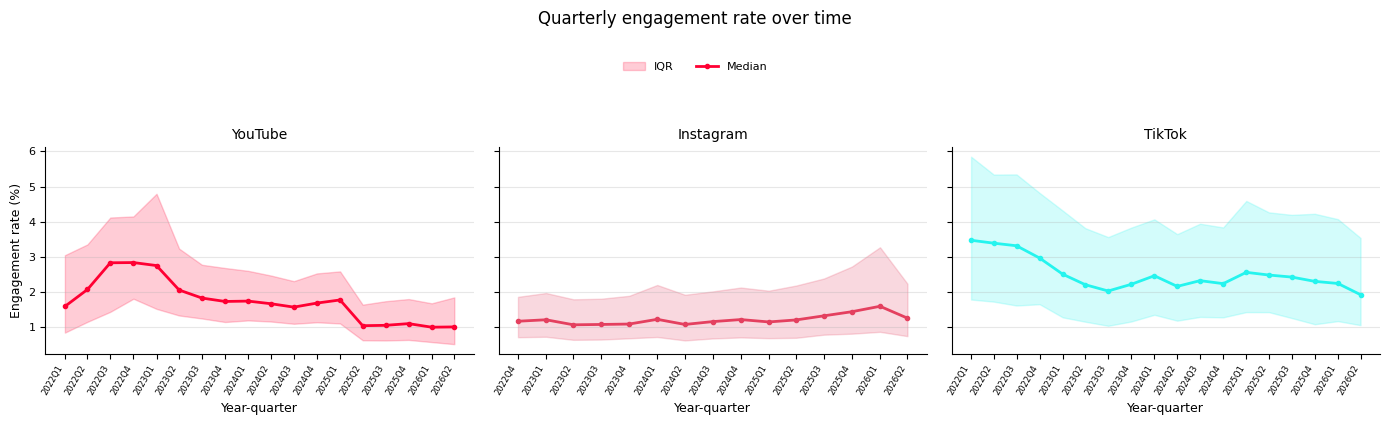

,platform,videos_before_plot_filter,videos_excluded_from_plot,videos_used_in_plot
0,YouTube,51856,0,51856
1,Instagram,233279,6999,226280
2,TikTok,194638,0,194638


,platform,year_quarter,median,q25,q75,mean,n_videos,year_quarter_date,year_quarter_label
0,Instagram,2022Q4,1.174,0.720,1.867,1.459,8232,2022-10-01,2022Q4
1,Instagram,2023Q1,1.216,0.733,1.976,1.516,8944,2023-01-01,2023Q1
2,Instagram,2023Q2,1.073,0.646,1.798,1.416,10493,2023-04-01,2023Q2
3,Instagram,2023Q3,1.083,0.654,1.814,1.453,11035,2023-07-01,2023Q3
4,Instagram,2023Q4,1.095,0.690,1.897,1.517,12378,2023-10-01,2023Q4
5,Instagram,2024Q1,1.229,0.727,2.205,1.729,13012,2024-01-01,2024Q1
6,Instagram,2024Q2,1.083,0.629,1.926,1.530,13780,2024-04-01,2024Q2
7,Instagram,2024Q3,1.164,0.685,2.022,1.652,12684,2024-07-01,2024Q3
8,Instagram,2024Q4,1.222,0.714,2.132,1.724,14232,2024-10-01,2024Q4
9,Instagram,2025Q1,1.154,0.693,2.042,1.660,17294,2025-01-01,2025Q1


In [14]:
# =============================================================================
# QUARTERLY ENGAGEMENT RATE
# Median + IQR over time
# One panel per platform
# =============================================================================

ENGAGEMENT_COL = "engagement_rate"
RATE_IS_PROPORTION = True
CAP_QUANTILE = 0.97

platform_order = ["YouTube", "Instagram", "TikTok"]

engagement_quarterly_data = []
plot_filter_report = []

# ---------------------------------------------------------
# 1. Prepare quarterly engagement data
# ---------------------------------------------------------

for platform in platform_order:

    df = datasets[platform].copy()

    df["platform"] = platform

    df["published_at"] = pd.to_datetime(
        df["published_at"],
        utc=True,
        errors="coerce"
    )

    df[ENGAGEMENT_COL] = pd.to_numeric(
        df[ENGAGEMENT_COL],
        errors="coerce"
    )

    df = df.dropna(subset=["published_at", ENGAGEMENT_COL])

    df = df[
        (df[ENGAGEMENT_COL] >= 0) &
        np.isfinite(df[ENGAGEMENT_COL])
    ].copy()

    df["year_quarter"] = (
        df["published_at"]
        .dt.tz_convert(None)
        .dt.to_period("Q")
    )

    if RATE_IS_PROPORTION:
        df["engagement_rate_plot"] = df[ENGAGEMENT_COL] * 100
    else:
        df["engagement_rate_plot"] = df[ENGAGEMENT_COL]

    before_plot_filter = len(df)

    # Same visualization cap logic as before
    if platform == "Instagram":

        instagram_cap = df["engagement_rate_plot"].quantile(CAP_QUANTILE)

        df = df[
            df["engagement_rate_plot"] <= instagram_cap
        ].copy()

        title_note = f"cap {int(CAP_QUANTILE * 100)}%"
    else:
        title_note = "full"

    after_plot_filter = len(df)

    plot_filter_report.append({
        "platform": platform,
        "videos_before_plot_filter": before_plot_filter,
        "videos_excluded_from_plot": before_plot_filter - after_plot_filter,
        "videos_used_in_plot": after_plot_filter
    })

    engagement_quarterly_data.append(df)

engagement_quarterly_data = pd.concat(
    engagement_quarterly_data,
    ignore_index=True
)

plot_filter_report = pd.DataFrame(plot_filter_report)

# ---------------------------------------------------------
# 2. Summarize by platform-quarter
# ---------------------------------------------------------

quarterly_engagement_summary = (
    engagement_quarterly_data
    .groupby(["platform", "year_quarter"])["engagement_rate_plot"]
    .agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        mean="mean",
        n_videos="count"
    )
    .reset_index()
)

quarterly_engagement_summary["year_quarter_date"] = (
    quarterly_engagement_summary["year_quarter"]
    .dt.to_timestamp()
)

quarterly_engagement_summary["year_quarter_label"] = (
    quarterly_engagement_summary["year_quarter"]
    .astype(str)
)

# ---------------------------------------------------------
# 3. Plot median + IQR
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1, 3,
    figsize=(14, 3.5),
    sharey=True
)

for ax, platform in zip(axes, platform_order):

    sub = (
        quarterly_engagement_summary[
            quarterly_engagement_summary["platform"] == platform
        ]
        .sort_values("year_quarter_date")
        .copy()
    )

    x = sub["year_quarter_date"].to_numpy()
    q25 = sub["q25"].to_numpy()
    q75 = sub["q75"].to_numpy()
    median = sub["median"].to_numpy()

    ax.fill_between(
        x,
        q25,
        q75,
        color=COLORS[platform],
        alpha=0.20,
        label="IQR"
    )

    ax.plot(
        x,
        median,
        color=COLORS[platform],
        linewidth=2,
        marker="o",
        markersize=3,
        label="Median"
    )

    ax.set_title(platform, fontsize=10)
    ax.set_xlabel("Year-quarter", fontsize=9)

    # Show all quarters and all years
    ax.set_xticks(x)

    ax.set_xticklabels(
        sub["year_quarter_label"],
        rotation=60,
        ha="right",
        fontsize=6
    )

    ax.grid(axis="y", alpha=0.3)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(axis="y", labelsize=8)

axes[0].set_ylabel("Engagement rate (%)", fontsize=9)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=2,
    frameon=False,
    fontsize=8
)

plt.suptitle(
    "Quarterly engagement rate over time",
    fontsize=12,
    y=1.20
)

plt.tight_layout()
plt.show()

display(plot_filter_report)
display(quarterly_engagement_summary.round(3))

# Attention concentration: top 1% share and Gini

In [16]:
# =============================================================================
# ATTENTION CONCENTRATION
# Top 1% share and Gini coefficient by platform and year
# =============================================================================
performance_metrics = ["views", "likes", "comments"]

metric_labels = {
    "views": "Views",
    "likes": "Likes",
    "comments": "Comments",
}

def gini_coefficient(x):
    """
    Compute the Gini coefficient for a non-negative numeric array.

    0 = perfectly equal distribution
    1 = maximum inequality

    In this context, a higher Gini means that attention is more concentrated
    among a small number of videos.
    """

    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna()
    x = x[x >= 0].to_numpy()

    if len(x) == 0:
        return np.nan

    if np.sum(x) == 0:
        return np.nan

    # Sort values from smallest to largest.
    # The Gini formula depends on the rank order of observations.
    x = np.sort(x)

    n = len(x)
    index = np.arange(1, n + 1)

    return (
        (2 * np.sum(index * x)) /
        (n * np.sum(x))
        - (n + 1) / n
    )


def top_share(x, top_pct=0.01):
    """
    Share of total metric value produced by the top X% of videos.
    Example: top_pct=0.01 gives the top 1% share.
    """

    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna()
    x = x[x >= 0].to_numpy()

    if len(x) == 0:
        return np.nan

    # Compute the total amount of attention/interactions.
    total = np.sum(x)

    if total == 0:
        return np.nan

    n_top = max(1, int(np.ceil(len(x) * top_pct)))

    top_sum = np.sum(
        np.sort(x)[-n_top:]
    )

    return top_sum / total

In [17]:
# =============================================================================
# BUILD OVERALL AND YEARLY CONCENTRATION TABLES
# =============================================================================

concentration_rows = []

for platform in platform_order:

    df = datasets[platform].copy()

    df["published_at"] = pd.to_datetime(
        df["published_at"],
        utc=True,
        errors="coerce"
    )

    df["year"] = df["published_at"].dt.year

    for metric in performance_metrics:

        df[metric] = pd.to_numeric(
            df[metric],
            errors="coerce"
        )

        # Overall platform-level concentration
        concentration_rows.append({
            "platform": platform,
            "year": "Overall",
            "metric": metric,
            "n_videos": df[metric].notna().sum(),
            "top_1pct_share": top_share(df[metric], top_pct=0.01),
            "gini": gini_coefficient(df[metric])
        })

        # Yearly concentration
        for year, group in df.groupby("year"):

            concentration_rows.append({
                "platform": platform,
                "year": year,
                "metric": metric,
                "n_videos": group[metric].notna().sum(),
                "top_1pct_share": top_share(group[metric], top_pct=0.01),
                "gini": gini_coefficient(group[metric])
            })

concentration_summary = pd.DataFrame(concentration_rows)

concentration_summary["top_1pct_share_pct"] = (
    concentration_summary["top_1pct_share"] * 100
)

concentration_summary = concentration_summary[
    [
        "platform",
        "year",
        "metric",
        "n_videos",
        "top_1pct_share_pct",
        "gini"
    ]
].round(3)

display(concentration_summary)

,platform,year,metric,n_videos,top_1pct_share_pct,gini
0,YouTube,Overall,views,51858,46.623,0.888
1,YouTube,2022,views,1966,67.871,0.952
2,YouTube,2023,views,3989,70.140,0.949
3,YouTube,2024,views,7589,57.577,0.908
4,YouTube,2025,views,21699,34.735,0.846
5,YouTube,2026,views,16615,23.175,0.837
6,YouTube,Overall,likes,51858,69.156,0.935
7,YouTube,2022,likes,1966,70.342,0.963
8,YouTube,2023,likes,3989,77.093,0.966
9,YouTube,2024,likes,7589,70.190,0.945


In [18]:
# =============================================================================
# OVERALL CONCENTRATION TABLE
# =============================================================================

overall_concentration = (
    concentration_summary
    .query("year == 'Overall'")
    .copy()
    .sort_values(["metric", "platform"])
)

display(overall_concentration)

,platform,year,metric,n_videos,top_1pct_share_pct,gini
30,Instagram,Overall,comments,233279,25.302,0.830
48,TikTok,Overall,comments,194812,28.575,0.861
12,YouTube,Overall,comments,51858,32.661,0.873
24,Instagram,Overall,likes,233279,24.775,0.815
42,TikTok,Overall,likes,194812,33.382,0.886
6,YouTube,Overall,likes,51858,69.156,0.935
18,Instagram,Overall,views,233279,17.822,0.763
36,TikTok,Overall,views,194812,25.329,0.833
0,YouTube,Overall,views,51858,46.623,0.888


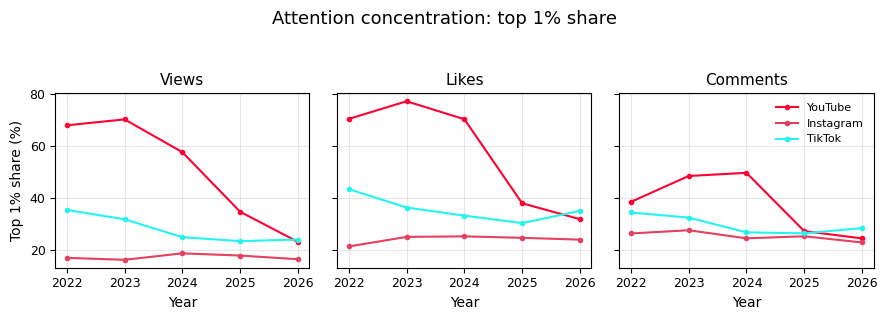

In [19]:
# =============================================================================
# YEARLY TOP 1% SHARE BY PLATFORM
# =============================================================================

yearly_concentration = (
    concentration_summary
    .query("year != 'Overall'")
    .copy()
)

yearly_concentration["year"] = yearly_concentration["year"].astype(int)



fig, axes = plt.subplots(
    1, 3,
    figsize=(9, 3),
    sharex=True,
    sharey=True
    )

for ax, metric in zip(axes, performance_metrics):

    for platform in platform_order:

        sub = yearly_concentration[
            (yearly_concentration["platform"] == platform) &
            (yearly_concentration["metric"] == metric)
        ].sort_values("year")

        ax.plot(
            sub["year"],
            sub["top_1pct_share_pct"],
            marker="o",
            markersize=3,
            linewidth=1.5,
            color=COLORS[platform],
            label=platform
        )

    ax.set_title(metric_labels[metric], fontsize=11)
    ax.set_xlabel("Year", fontsize=10)
    ax.grid(alpha=0.3)
    ax.tick_params(axis="both", labelsize=9)
    
    axes[0].set_ylabel("Top 1% share (%)", fontsize=10)

axes[-1].legend(
    frameon=False,
    fontsize=8,
    loc="upper right"
)

plt.suptitle(
    "Attention concentration: top 1% share",
    fontsize=13,
    y=1.05
)

plt.tight_layout()
plt.show()

## Checking the Attention

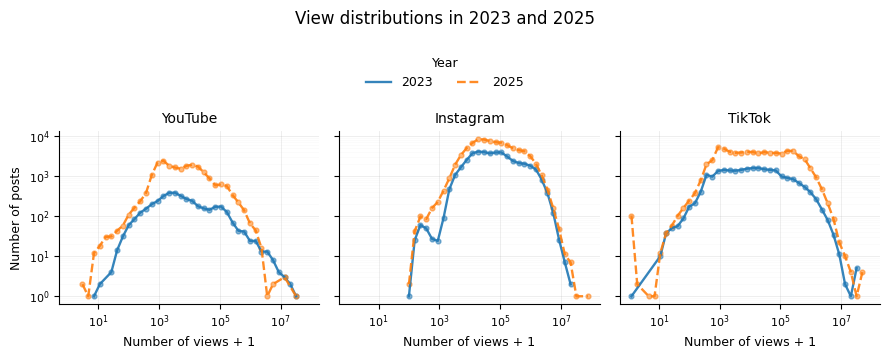

In [20]:
# =============================================================================
# VIEW DISTRIBUTIONS — 2023 VS 2025
# x-axis: number of views + 1
# y-axis: number of posts/videos
# one panel per platform
# =============================================================================

years_to_plot = [2023, 2025]
platform_order = ["YouTube", "Instagram", "TikTok"]

year_colors = {
    2023: "#1F77B4",   
    2025: "#FF7F0E",  
}

year_linestyles = {
    2023: "-",
    2025: "--",
}

N_BINS = 45

# ---------------------------------------------------------
# Define common log-spaced bins across all platforms/years
# ---------------------------------------------------------

all_values = []

for platform in platform_order:

    df = datasets[platform].copy()

    df["published_at"] = pd.to_datetime(
        df["published_at"],
        utc=True,
        errors="coerce"
    )

    df["year"] = df["published_at"].dt.year

    df["views"] = pd.to_numeric(
        df["views"],
        errors="coerce"
    )

    df = df[df["year"].isin(years_to_plot)].copy()

    values = df["views"].dropna()
    values = values[
        (values >= 0) &
        np.isfinite(values)
    ] + 1

    all_values.append(values)

all_values = pd.concat(
    all_values,
    ignore_index=True
)

bins = np.logspace(
    np.log10(all_values.min()),
    np.log10(all_values.max()),
    N_BINS
)

bin_centers = np.sqrt(
    bins[:-1] * bins[1:]
)

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1, 3,
    figsize=(9, 3),
    sharex=True,
    sharey=True
)

for ax, platform in zip(axes, platform_order):

    df = datasets[platform].copy()

    df["published_at"] = pd.to_datetime(
        df["published_at"],
        utc=True,
        errors="coerce"
    )

    df["year"] = df["published_at"].dt.year

    df["views"] = pd.to_numeric(
        df["views"],
        errors="coerce"
    )

    for year in years_to_plot:

        sub = df[df["year"] == year].copy()

        values = sub["views"].dropna()
        values = values[
            (values >= 0) &
            np.isfinite(values)
        ] + 1

        counts, _ = np.histogram(
            values,
            bins=bins
        )

        nonzero = counts > 0

        ax.plot(
            bin_centers[nonzero],
            counts[nonzero],
            color=year_colors[year],
            linestyle=year_linestyles[year],
            linewidth=1.7,
            alpha=0.9,
            label=str(year)
        )

        ax.scatter(
            bin_centers[nonzero],
            counts[nonzero],
            color=year_colors[year],
            s=12,
            alpha=0.55
        )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_title(platform, fontsize=10, color="black")
    ax.set_xlabel("Number of views + 1", fontsize=9)

    ax.grid(
        which="major",
        alpha=0.25,
        linewidth=0.6
    )

    ax.grid(
        which="minor",
        alpha=0.08,
        linewidth=0.4
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=8
    )

    ax.tick_params(
        axis="both",
        which="minor",
        length=0
    )

    ax.xaxis.set_major_locator(
        mticker.LogLocator(base=10)
    )

    ax.yaxis.set_major_locator(
        mticker.LogLocator(base=10)
    )

    ax.xaxis.set_minor_formatter(
        mticker.NullFormatter()
    )

    ax.yaxis.set_minor_formatter(
        mticker.NullFormatter()
    )

axes[0].set_ylabel("Number of posts", fontsize=9)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.06),
    ncol=2,
    frameon=False,
    fontsize=9,
    title="Year",
    title_fontsize=9
)

plt.suptitle(
    "View distributions in 2023 and 2025",
    fontsize=12,
    y=1.18
)

plt.tight_layout()
plt.show()

# GINI Coefficient 

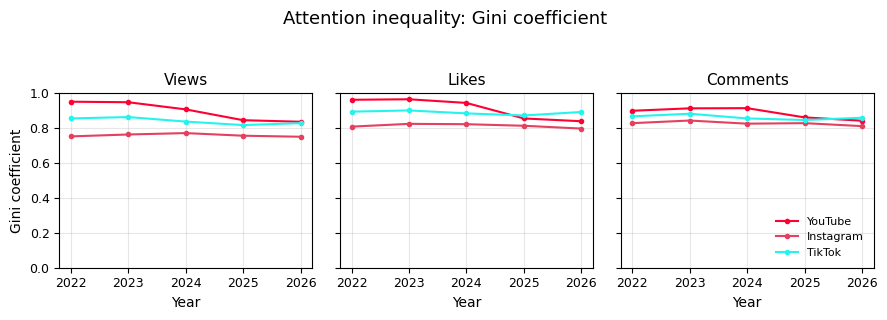

In [21]:
# =============================================================================
# YEARLY GINI COEFFICIENT BY PLATFORM
# =============================================================================

fig, axes = plt.subplots(
    1, 3,
    figsize=(9, 3),
    sharex=True,
    sharey=True
)

for ax, metric in zip(axes, performance_metrics):

    for platform in platform_order:

        sub = yearly_concentration[
            (yearly_concentration["platform"] == platform) &
            (yearly_concentration["metric"] == metric)
        ].sort_values("year")

        ax.plot(
            sub["year"],
            sub["gini"],
            marker="o",
            markersize=3,
            linewidth=1.5,
            color=COLORS[platform],
            label=platform
        )

    ax.set_title(metric_labels[metric], fontsize=11)
    ax.set_xlabel("Year", fontsize=10)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.tick_params(axis="both", labelsize=9)

axes[0].set_ylabel("Gini coefficient", fontsize=10)

axes[-1].legend(
    frameon=False,
    fontsize=8,
    loc="lower right"
)

plt.suptitle(
    "Attention inequality: Gini coefficient",
    fontsize=13,
    y=1.05
)

plt.tight_layout()
plt.show()

# Reach-engagement relationship

In [22]:
# =============================================================================
# REACH-ENGAGEMENT RELATIONSHIP
# Spearman correlation between views and engagement rates
# =============================================================================

engagement_metrics = ["like_rate", "comment_rate", "engagement_rate"]

engagement_labels = {
    "like_rate": "Like rate",
    "comment_rate": "Comment rate",
    "engagement_rate": "Engagement rate",
}

reach_engagement_rows = []

for platform in platform_order:

    df = datasets[platform].copy()

    df["published_at"] = pd.to_datetime(
        df["published_at"],
        utc=True,
        errors="coerce"
    )

    df["year"] = df["published_at"].dt.year

    df["views"] = pd.to_numeric(
        df["views"],
        errors="coerce"
    )

    for metric in engagement_metrics:

        df[metric] = pd.to_numeric(
            df[metric],
            errors="coerce"
        )

        # Overall correlation
        temp = df[["views", metric]].dropna()
        temp = temp[
            (temp["views"] > 0) &
            (temp[metric] >= 0) &
            np.isfinite(temp["views"]) &
            np.isfinite(temp[metric])
        ]

        reach_engagement_rows.append({
            "platform": platform,
            "year": "Overall",
            "engagement_metric": metric,
            "n_videos": len(temp),
            "spearman_corr": temp["views"].corr(
                temp[metric],
                method="spearman"
            )
        })

        # Yearly correlation
        for year, group in df.groupby("year"):

            temp = group[["views", metric]].dropna()
            temp = temp[
                (temp["views"] > 0) &
                (temp[metric] >= 0) &
                np.isfinite(temp["views"]) &
                np.isfinite(temp[metric])
            ]

            reach_engagement_rows.append({
                "platform": platform,
                "year": year,
                "engagement_metric": metric,
                "n_videos": len(temp),
                "spearman_corr": temp["views"].corr(
                    temp[metric],
                    method="spearman"
                )
            })

reach_engagement_summary = pd.DataFrame(reach_engagement_rows)

reach_engagement_summary = reach_engagement_summary.round(3)

display(reach_engagement_summary)

,platform,year,engagement_metric,n_videos,spearman_corr
0,YouTube,Overall,like_rate,51856,-0.001
1,YouTube,2022,like_rate,1966,0.157
2,YouTube,2023,like_rate,3989,0.089
3,YouTube,2024,like_rate,7588,0.039
4,YouTube,2025,like_rate,21699,0.107
5,YouTube,2026,like_rate,16614,-0.116
6,YouTube,Overall,comment_rate,51856,0.346
7,YouTube,2022,comment_rate,1966,0.328
8,YouTube,2023,comment_rate,3989,0.318
9,YouTube,2024,comment_rate,7588,0.349


In [23]:
# =============================================================================
# OVERALL REACH-ENGAGEMENT CORRELATION TABLE
# =============================================================================

overall_reach_engagement = (
    reach_engagement_summary
    .query("year == 'Overall'")
    .copy()
    .sort_values(["engagement_metric", "platform"])
)

display(overall_reach_engagement)

,platform,year,engagement_metric,n_videos,spearman_corr
24,Instagram,Overall,comment_rate,233279,0.178
42,TikTok,Overall,comment_rate,194638,0.225
6,YouTube,Overall,comment_rate,51856,0.346
30,Instagram,Overall,engagement_rate,233279,0.131
48,TikTok,Overall,engagement_rate,194638,0.142
12,YouTube,Overall,engagement_rate,51856,0.030
18,Instagram,Overall,like_rate,233279,0.126
36,TikTok,Overall,like_rate,194638,0.139
0,YouTube,Overall,like_rate,51856,-0.001


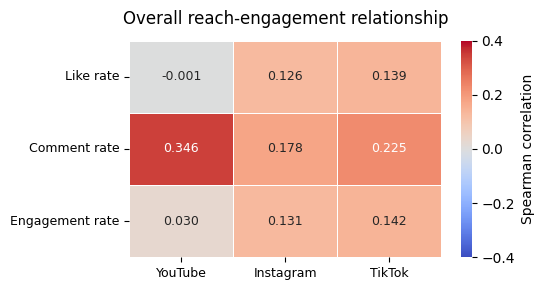

In [24]:
# =============================================================================
# OVERALL REACH-ENGAGEMENT CORRELATION HEATMAP
# Rows = engagement metrics
# Columns = platforms
# Values = Spearman correlations
# =============================================================================


metric_order = ["like_rate", "comment_rate", "engagement_rate"]

metric_labels = {
    "like_rate": "Like rate",
    "comment_rate": "Comment rate",
    "engagement_rate": "Engagement rate"
}

platform_order = ["YouTube", "Instagram", "TikTok"]

heatmap_data = (
    overall_reach_engagement
    .pivot(
        index="engagement_metric",
        columns="platform",
        values="spearman_corr"
    )
    .reindex(index=metric_order, columns=platform_order)
    .rename(index=metric_labels)
)

plt.figure(figsize=(5.5, 3))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    vmin=-0.4,
    vmax=0.4,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={
        "label": "Spearman correlation"
    },
    annot_kws={
        "fontsize": 9
    }
)

plt.title(
    "Overall reach-engagement relationship",
    fontsize=12,
    pad=12
)

plt.xlabel("")
plt.ylabel("")

plt.xticks(
    rotation=0,
    fontsize=9
)

plt.yticks(
    rotation=0,
    fontsize=9
)

plt.tight_layout()
plt.show()